# 04. Model Training

In [1]:
# 01. APRENDIZADO DE MÁQUINA (CLASSIFICAÇÃO PREDITIVA)

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings

warnings.filterwarnings("ignore")

print("="*80)
print(" Iniciando avaliação do modelo final (XGBOOST + K=15)")
print("="*80)

# 1. Carregamento e Isolamento da Tarefa
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

SEED = 97
cv_strategy = LeaveOneOut() # LOOCV (N=42)

condicoes_busca = {
    'Face Feliz': ['Face Feliz'],
    'Face Neutra': ['Face Neutra'],
    'Face Raiva': ['Face Raiva']
}

# 2. Pipeline Final
pipeline_classificacao = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=15)),
    ('clf', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, 
                          eval_metric='logloss', random_state=SEED))
])

# 3. Validação e Extração de Métricas
for nome_condicao, lista_triggers in condicoes_busca.items():
    print(f"\n" + "-"*60)
    print(f"ESTÍMULO ANALISADO: {nome_condicao.upper()}")
    print("-" * 60)
    
    df_f = df[df['Condicao'].isin(lista_triggers)].copy()
    
    if df_f.empty:
        print(f"Atenção: Sem dados para {nome_condicao}.")
        continue

    # Garantia de integridade amostral (N=42)
    df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()
    print(f"Amostra consolidada: {df_f.shape[0]} sujeitos.\n")

    y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
    X = df_f.drop(columns=['ID', 'Grupo', 'Condicao', 'Tipo'], errors='ignore')

    # Predição Cega (LOOCV)
    y_pred = cross_val_predict(pipeline_classificacao, X, y, cv=cv_strategy)

    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)

    print(f" ACURÁCIA GLOBAL DO SISTEMA: {acc:.2%}\n")

    print("Matriz de Confusão:")
    print(f"                   Predito Controle (0) | Predito TEA (1)")
    print(f"Real Controle (0) |        {cm[0,0]:02d}           |        {cm[0,1]:02d}")
    print(f"Real TEA (1)      |        {cm[1,0]:02d}           |        {cm[1,1]:02d}\n")

    print("Relatório de Desempenho (Precision, Recall, F1-Score):")
    report = classification_report(y, y_pred, target_names=['Controle', 'TEA'], digits=3)
    print(report)

print("="*80)

 Iniciando avaliação do modelo final (XGBOOST + K=15)

------------------------------------------------------------
ESTÍMULO ANALISADO: FACE FELIZ
------------------------------------------------------------
Amostra consolidada: 42 sujeitos.

 ACURÁCIA GLOBAL DO SISTEMA: 83.33%

Matriz de Confusão:
                   Predito Controle (0) | Predito TEA (1)
Real Controle (0) |        21           |        03
Real TEA (1)      |        04           |        14

Relatório de Desempenho (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

    Controle      0.840     0.875     0.857        24
         TEA      0.824     0.778     0.800        18

    accuracy                          0.833        42
   macro avg      0.832     0.826     0.829        42
weighted avg      0.833     0.833     0.833        42


------------------------------------------------------------
ESTÍMULO ANALISADO: FACE NEUTRA
------------------------------------------------------------


In [3]:
import pandas as pd
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, f1_score
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

print(" Calculando métricas clínicas globais para todas as Faces...\n")

# Carregamento dos Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
try:
    df = pd.read_csv(caminho_csv)
except FileNotFoundError:
    df = pd.read_csv('reports/tabela_features_eeg_completa.csv')

condicoes = {
    'FF': 'Face Feliz',
    'FN': 'Face Neutra',
    'FR': 'Face Raiva'
}

# Cabeçalho da Tabela
print("Tabela - Acurácia Global do modelo XGBoost para os dados de EEG")
print("-" * 75)
print(f"{'EEG':<5} | {'Acurácia':<10} | {'Sensibilidade':<15} | {'Precisão':<10} | {'F1-Score':<10} | {'AUC-ROC':<10}")
print("-" * 75)

for sigla, condicao in condicoes.items():
    df_cond = df[df['Condicao'] == condicao].copy()
    
    if df_cond.empty:
        print(f"{sigla:<5} | Sem dados para esta condição")
        continue

    # Agrupamento e definição de variáveis
    df_cond = df_cond.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()
    y = df_cond['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
    X = df_cond.drop(columns=['ID', 'Grupo', 'Condicao', 'Tipo'], errors='ignore')

    # Pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', RobustScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=15)),
        ('clf', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, 
                              eval_metric='logloss', random_state=97))
    ])

    # Predições LOOCV
    cv = LeaveOneOut()
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    y_probs = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

    # Cálculos Matemáticos
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y, y_pred) * 100
    sens = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    prec = (precision_score(y, y_pred, zero_division=0) * 100)
    f1 = (f1_score(y, y_pred, zero_division=0) * 100)
    
    # Transformando AUC para formato de porcentagem
    auc = (roc_auc_score(y, y_probs) * 100) 

    # Impressão da linha formatada
    print(f"{sigla:<5} | {acc:>6.2f}%   | {sens:>12.2f}%  | {prec:>7.2f}%  | {f1:>7.2f}%  | {auc:>7.2f}%")

print("-" * 75)

 Calculando métricas clínicas globais para todas as Faces...

Tabela - Acurácia Global do modelo XGBoost para os dados de EEG
---------------------------------------------------------------------------
EEG   | Acurácia   | Sensibilidade   | Precisão   | F1-Score   | AUC-ROC   
---------------------------------------------------------------------------
FF    |  83.33%   |        77.78%  |   82.35%  |   80.00%  |   74.07%
FN    |  57.14%   |        50.00%  |   50.00%  |   50.00%  |   63.66%
FR    |  64.29%   |        44.44%  |   61.54%  |   51.61%  |   68.75%
---------------------------------------------------------------------------


In [2]:
#TESTE
import pandas as pd
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, f1_score
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

print(" Calculando métricas clínicas globais para todas as Faces...\n")

# Carregamento dos Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
try:
    df = pd.read_csv(caminho_csv)
except FileNotFoundError:
    df = pd.read_csv('reports/tabela_features_eeg_completa.csv')

condicoes = {
    'FF': 'Face Feliz',
    'FN': 'Face Neutra',
    'FR': 'Face Raiva'
}

# Cabeçalho da Tabela
print("Tabela - Acurácia Global do modelo XGBoost para os dados de EEG")
print("-" * 75)
print(f"{'EEG':<5} | {'Acurácia':<10} | {'Sensibilidade':<15} | {'Precisão':<10} | {'F1-Score':<10} | {'AUC-ROC':<10}")
print("-" * 75)

for sigla, condicao in condicoes.items():
    df_cond = df[df['Condicao'] == condicao].copy()
    
    if df_cond.empty:
        print(f"{sigla:<5} | Sem dados para esta condição")
        continue

    # Agrupamento e definição de variáveis
    df_cond = df_cond.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()
    y = df_cond['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
    X = df_cond.drop(columns=['ID', 'Grupo', 'Condicao', 'Tipo'], errors='ignore')

    # Pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', RobustScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=5)),
        ('clf', XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, 
                              eval_metric='logloss', random_state=97))
    ])

    # Predições LOOCV
    cv = LeaveOneOut()
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    y_probs = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

    # Cálculos Matemáticos
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y, y_pred) * 100
    sens = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    prec = (precision_score(y, y_pred, zero_division=0) * 100)
    f1 = (f1_score(y, y_pred, zero_division=0) * 100)
    
    # Transformando AUC para formato de porcentagem
    auc = (roc_auc_score(y, y_probs) * 100) 

    # Impressão da linha formatada
    print(f"{sigla:<5} | {acc:>6.2f}%   | {sens:>12.2f}%  | {prec:>7.2f}%  | {f1:>7.2f}%  | {auc:>7.2f}%")

print("-" * 75)

 Calculando métricas clínicas globais para todas as Faces...

Tabela - Acurácia Global do modelo XGBoost para os dados de EEG
---------------------------------------------------------------------------
EEG   | Acurácia   | Sensibilidade   | Precisão   | F1-Score   | AUC-ROC   
---------------------------------------------------------------------------
FF    |  83.33%   |        77.78%  |   82.35%  |   80.00%  |   81.94%
FN    |  54.76%   |        44.44%  |   47.06%  |   45.71%  |   68.75%
FR    |  64.29%   |        55.56%  |   58.82%  |   57.14%  |   66.90%
---------------------------------------------------------------------------


⏳ Extraindo as regras biológicas do XGBoost para as 3 condições...

------------------------------------------------------------
 PROCESSANDO: FACE FELIZ
------------------------------------------------------------


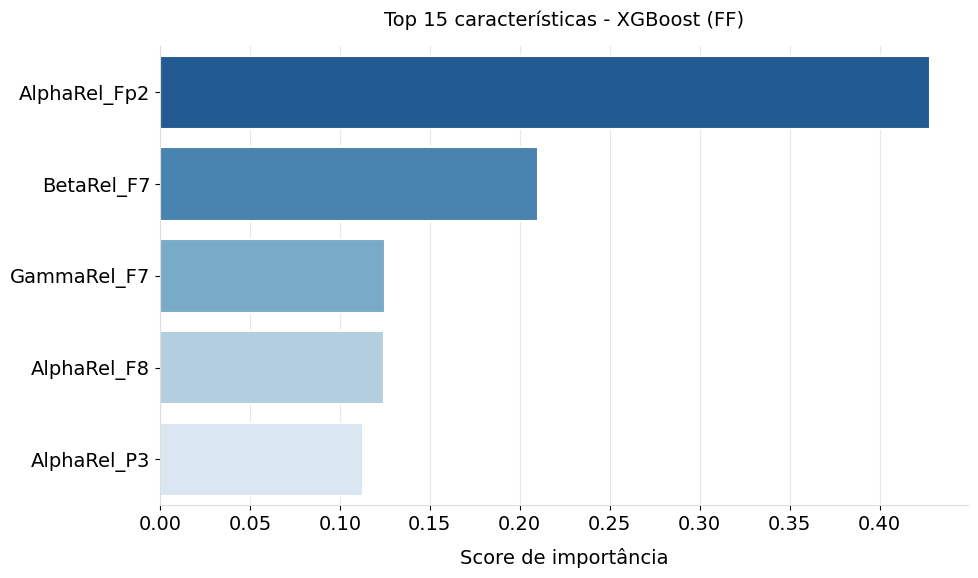

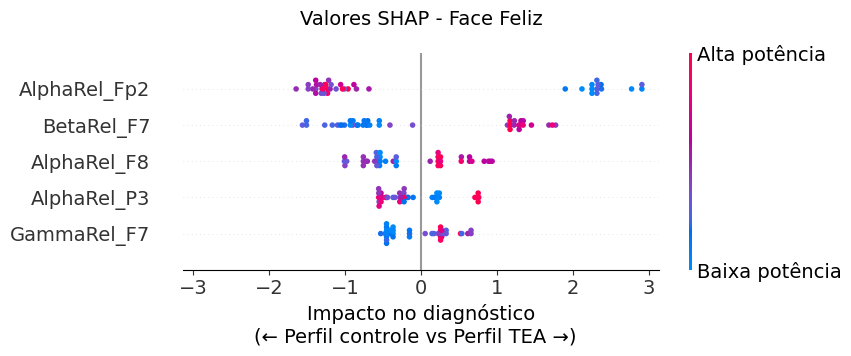


------------------------------------------------------------
 PROCESSANDO: FACE NEUTRA
------------------------------------------------------------


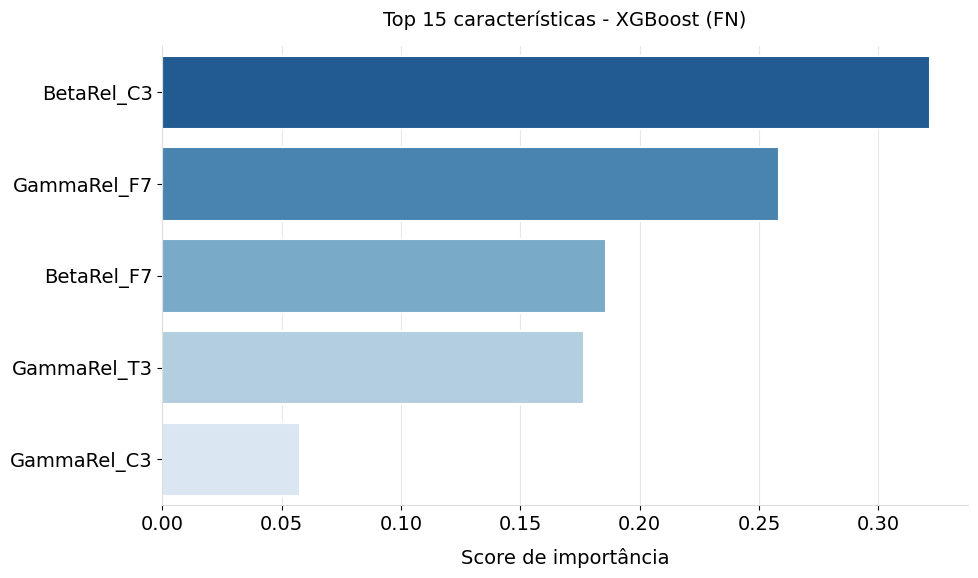

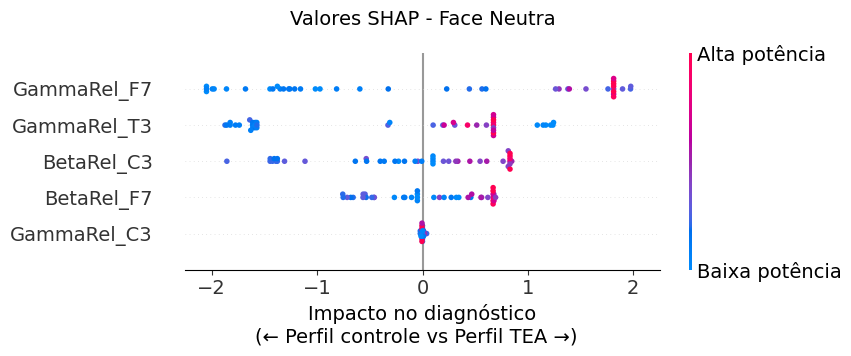


------------------------------------------------------------
 PROCESSANDO: FACE RAIVA
------------------------------------------------------------


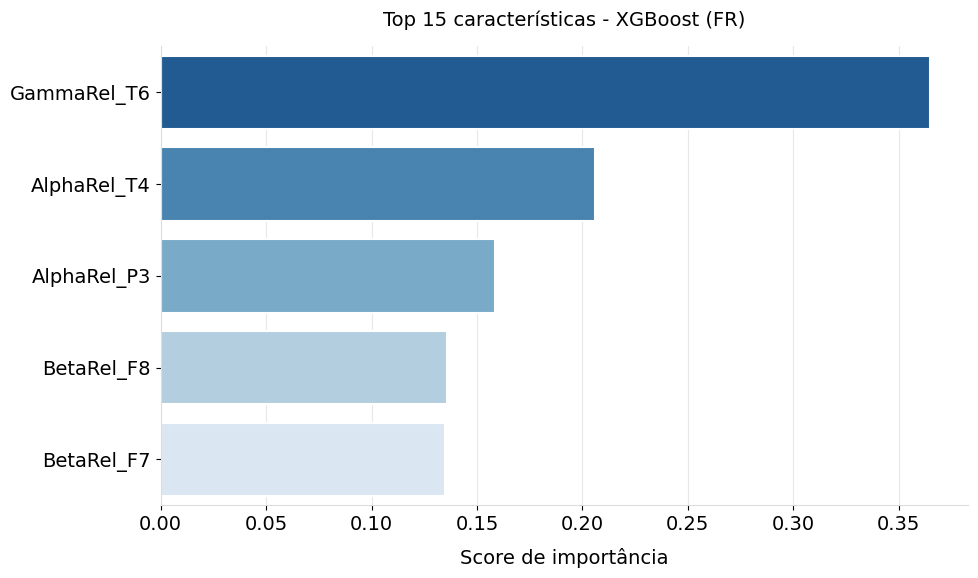

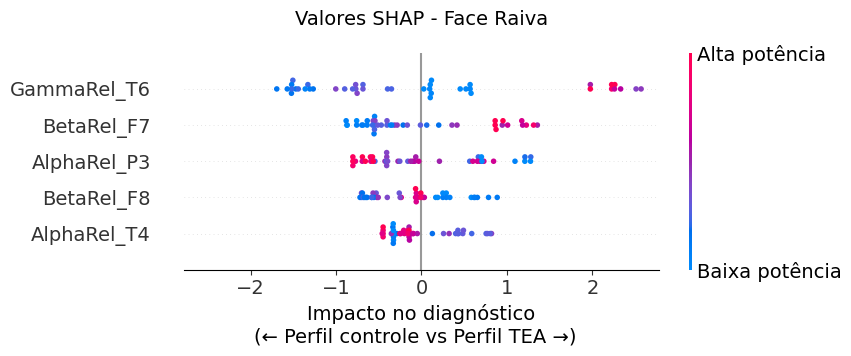


✅ Todas as imagens foram processadas.


In [3]:
# teste

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import os
import warnings

try:
    import shap
except ImportError:
    print("⚠️ A biblioteca 'shap' não está instalada. Execute '!pip install shap' e rode novamente.")
    shap = None

warnings.filterwarnings("ignore")

print("⏳ Extraindo as regras biológicas do XGBoost para as 3 condições...")

# 1. Configurações Visuais Estritas
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

# Dicionário com os nomes das condições e suas siglas para o título
condicoes = {
    'Face Feliz': 'FF',
    'Face Neutra': 'FN',
    'Face Raiva': 'FR'
}

SEED = 97

for nome_condicao, sigla in condicoes.items():
    print(f"\n" + "-"*60)
    print(f" PROCESSANDO: {nome_condicao.upper()}")
    print("-"*60)
    
    df_f = df[df['Condicao'] == nome_condicao].copy()
    if df_f.empty:
        print(f"Atenção: Sem dados para {nome_condicao}. Pulando...")
        continue
        
    df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()
    
    y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
    X_bruto = df_f.drop(columns=['ID', 'Grupo', 'Condicao', 'Tipo'], errors='ignore')

    # Pipeline de Pré-processamento
    imputer = SimpleImputer(strategy='mean')
    X_imp = imputer.fit_transform(X_bruto)

    scaler = RobustScaler()
    X_sca = scaler.fit_transform(X_imp)

    selector = SelectKBest(score_func=f_classif, k=5)
    X_sel = selector.fit_transform(X_sca, y)

    indices_selecionados = selector.get_support(indices=True)
    nomes_features = X_bruto.columns[indices_selecionados]

    # Treinamento Global
    xgb_modelo = XGBClassifier(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.1, 
        eval_metric='logloss', 
        random_state=SEED
    )
    xgb_modelo.fit(X_sel, y)

    # 1 - FEATURE IMPORTANCE PLOTS
    importancias = xgb_modelo.feature_importances_
    df_imp = pd.DataFrame({
        'Variável': nomes_features,
        'Importância': importancias
    }).sort_values(by='Importância', ascending=False)

    fig1, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_axisbelow(True)

    sns.barplot(data=df_imp, x='Importância', y='Variável', palette='Blues_r', edgecolor='white', linewidth=1.5, ax=ax1)

    # Ajustes de título e legenda do Feature Importance
    ax1.set_title(f'Top 15 características - XGBoost ({sigla})', pad=15)
    ax1.set_xlabel('Score de importância', labelpad=10)
    ax1.set_ylabel('')

    ax1.grid(axis='x', linestyle='-', alpha=0.3, color='#B0B0B0')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#DDDDDD')
    ax1.spines['bottom'].set_color('#DDDDDD')

    plt.tight_layout()
    os.makedirs('../reports/figures', exist_ok=True)
    caminho_fig3a = f'../reports/figures/fig03_feature_importance_{sigla.lower()}.png'
    plt.savefig(caminho_fig3a, dpi=300, bbox_inches='tight')
    plt.show()

    # 2 - SHAP VALUES (Solução Nativa via XGBoost)
    if shap is not None:
        fig2 = plt.figure(figsize=(10, 6))
        
        # 1. Extraímos o motor nativo do XGBoost
        booster = xgb_modelo.get_booster()
        
        # 2. Convertemos os dados para o formato nativo do XGBoost para cálculo
        dmatrix = xgb.DMatrix(X_sel, feature_names=list(nomes_features))
        
        # 3. O próprio XGBoost calcula os SHAP Values internamente.
        # O parâmetro pred_contribs=True retorna a matriz exata que o SHAP precisa.
        shap_contribs = booster.predict(dmatrix, pred_contribs=True)
        
        # O XGBoost devolve os SHAP values de cada feature + 1 coluna extra no final (valor base).
        # Removemos a última coluna (:-1) para ficar só com a influência das variáveis.
        shap_values_tea = shap_contribs[:, :-1]

        plt.title(f'Valores SHAP - {nome_condicao}', pad=20, fontsize=14)
        
        # 4. Usamos o SHAP apenas como "desenhista", passando a matriz que já calculamos
        shap.summary_plot(shap_values_tea, X_sel, feature_names=list(nomes_features), show=False)
        
        # Centralização do eixo x
        ax2 = plt.gca()
        limites_x = ax2.get_xlim()
        max_abs = max(abs(limites_x[0]), abs(limites_x[1]))
        ax2.set_xlim(-max_abs, max_abs) 
        
        ax2.set_xlabel('Impacto no diagnóstico\n(← Perfil controle vs Perfil TEA →)  ', fontsize=14, fontweight='normal')
        ax2.tick_params(axis='both', labelsize=14)
        
        # Ajuste dos rótulos do eixo Y (Colorbar)
        fig = plt.gcf()
        for ax in fig.axes:
            if ax != ax2: 
                ax.set_ylabel('') 
                ax.set_yticks([0, 1])
                ax.set_yticklabels(['Baixa potência', 'Alta potência'], fontsize=14, fontweight='normal')
                ax.tick_params(length=0) 
        
        # Salvamento da imagem
        caminho_fig3b = f'../reports/figures/figTESTE_shap_values_{sigla.lower()}.png'
        plt.savefig(caminho_fig3b, dpi=300, bbox_inches='tight')
        plt.show()

print("\n✅ Todas as imagens foram processadas.")